# Project Information

## Competition name

AI Immune System Challenge

## Objective

Build a machine learning model capable of identifying dangerous or unsafe statements embedded within AI agent conversations. The goal is to detect harmful intent even when it is expressed indirectly, subtly, or through natural-sounding language.

## Target column

Target label column in the training dataset (TRUE/FALSE).

### Files
train_labeled_comp.jsonl — Training data containing conversations and labels.
test_labled_comp.jsonl — Test data used for prediction.
solution_format.csv — Example submission format.

## Prediction Task

This is a supervised machine learning classification problem. Given an AI agent conversation or statement, the model must predict whether it contains dangerous or unsafe intent.

Input:

AI agent conversation text

Output:

TRUE or FALSE

## What Does TRUE & FALSE Mean?

TRUE - Harmful conversation

Examples:

Harmful instructions
Unsafe recommendations
Dangerous agent behavior
Malicious or risky actions
What Does FALSE Mean?

FALSE - Non-harmful conversation

Examples:

Ordinary discussions
Safe recommendations
Normal agent interactions
Benign problem-solving conversations


## Machine Learning Problem Type
Supervised Learning
Binary Classification
Natural Language Processing (NLP)
AI Safety
Anomaly/Risk Detection


# Dataset Structure Investigation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
train_df = pd.read_json("../data/raw/train_labeled_comp.jsonl", lines=True)

In [6]:
train_df.head()

,label,text
0,FALSE,Although some of its components intersect deep...
1,FALSE,Losing excess WEIGHT can help jokers take off ...
2,FALSE,Crazy how many types dayalilyami has them! Bas...
3,FALSE,"Inevitably someone will lose pollen, use the w..."
4,FALSE,Topics might even be blurred through this proc...


In [12]:
train_df.dtypes

label    str
text     str
dtype: object

In [13]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4900 entries, 0 to 4899
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   4900 non-null   str  
 1   text    4900 non-null   str  
dtypes: str(2)
memory usage: 76.7 KB


In [15]:
train_df.describe()

,label,text
count,4900,4900
unique,2,4899
top,FALSE,[DECODE ERROR] Invalid character found in input.
freq,3500,2


In [16]:
train_df.shape

(4900, 2)

In [19]:
train_df.columns

Index(['label', 'text'], dtype='str')

In [20]:
train_df.isnull().sum()

label    0
text     0
dtype: int64

In [21]:
train_df['label'].value_counts()

label
FALSE    3500
TRUE     1400
Name: count, dtype: int64

In [22]:
train_df["label"].value_counts(normalize=True) * 100

label
FALSE    71.428571
TRUE     28.571429
Name: proportion, dtype: float64

In [23]:
train_df.duplicated().sum()

np.int64(0)

In [24]:
# Text length analysis
train_df["Text_Length"] = train_df['text'].str.len()
train_df["Text_Length"].describe()

count    4900.000000
mean      148.632857
std        81.831892
min        16.000000
25%       102.000000
50%       135.000000
75%       177.000000
max      1163.000000
Name: Text_Length, dtype: float64

In [ ]:
print(train_df['text'].iloc[0])

type(train_df["text"].iloc[0])


Although some of its components intersect deeper into its mechanics and science, the game of chess is still considered a form of art.


str

## Label Distribution Analysis

label
FALSE    3500
TRUE     1400
Name: count, dtype: int64


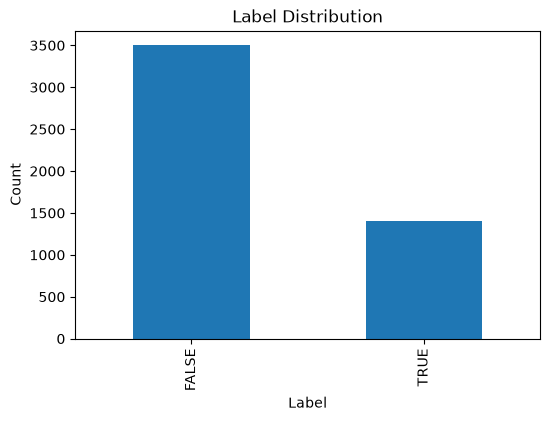

In [35]:
# Visualize Label Counts

label_counts = train_df['label'].value_counts()

print(label_counts)

plt.figure(figsize=(6,4))
label_counts.plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

label
FALSE    71.428571
TRUE     28.571429
Name: proportion, dtype: float64


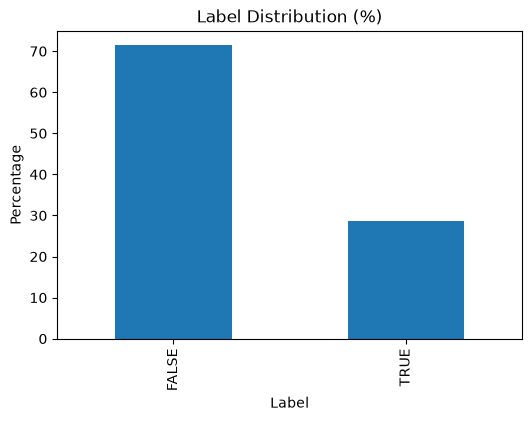

In [37]:
label_percentages = train_df["label"].value_counts(normalize=True) * 100

print(label_percentages)

plt.figure(figsize=(6,4))
label_percentages.plot(kind="bar")

plt.title("Label Distribution (%)")
plt.xlabel("Label")
plt.ylabel("Percentage")

plt.show()

In [ ]:
# compare the majority class to the minority class

label_counts = train_df["label"].value_counts()

imbalance_ratio = (
    label_counts["FALSE"] /
    label_counts["TRUE"]
)

print("Imbalance Ratio:", imbalance_ratio)

Imbalance Ratio: 2.5
